In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
print('Running...')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Running...


Last updated on 260205 for TR1-2026

# My team
* Sushmoy Paul Rohit
* Ornysha Biswas
* Mohammad Ramiz Karim

# Credit Member Statement 
This form is to recognise individual member contributions, reducing member disputes and facilitating collaboration within group. Please have a discussion on this within your group and insert this credit member statement here.

Sushmoy Paul Rohit: 
Decision Tree (Classification)
K-Means (Clustering)
Apriori (ARM)
Link to his/her notebook with individual solutions for this project

Ornysha Biswas:
Naive Bayes
Hierarchical clustering
FP-Growth

Mohammad Ramiz Karim:
KNN / SVM
DBSCAN
ARM variation

# Task 1: Dataset

The first step is to find your own domain-specific dataset for your data mining project. The dataset should be complex enough so that it is not straightforward to find patterns with simple calculations (impossible without preprocessing and data mining approaches). There is no limit in size for the dataset, but typically a good sized data for mining is around 100k-100M. Minimum of around 50k-100k samples/rows and minimum of around 50-100 attributes/columns. Get your dataset approved by your instructor before proceeding.

It could have thousands/millions rows (or columns or sometimes both rows/columns). A good data typically contains various types of data (numerical, nominal, ordinal, Boolean etc) with some errors (missing or dirty values etc) in the data. The dataset could contain text data, tabular formatted data, georeferenced data. See possible data sources: Kaggle repository (https://www.kaggle.com/datasets).

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.cluster import KMeans
from mlxtend.frequent_patterns import apriori, association_rules

In [3]:
import os
base_path = "/kaggle/input/datasets/aissaouihamda/international-football-matches-1872-present"
for root, dirs, files in os.walk(base_path):
    print(root, files)

/kaggle/input/datasets/aissaouihamda/international-football-matches-1872-present ['results.csv']


In [4]:
df = pd.read_csv(
    '/kaggle/input/datasets/aissaouihamda/international-football-matches-1872-present/results.csv',
    encoding='latin1'
)
df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,id
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,1
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,2
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,3
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,4
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,5


In [5]:
# Create match result column
def get_result(row):
    if row['home_score'] > row['away_score']:
        return 'Win'
    elif row['home_score'] < row['away_score']:
        return 'Loss'
    else:
        return 'Draw'

df['result'] = df.apply(get_result, axis=1)

df.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,id,result
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,1,Draw
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,2,Win
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,3,Win
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,4,Draw
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,5,Win



**The dataset used in this project contains international football match results from 1872 to the present. It was selected because it provides a large and diverse collection of real-world data, including match outcomes, team performance, and tournament information.One of the most interesting aspects of this dataset is its long historical range, which allows us to analyse patterns and trends in football over time. It includes matches from different countries, competitions, and conditions, making it suitable for applying multiple data mining techniques.This dataset is particularly useful because it contains both numerical data (such as scores) and categorical data (such as teams and tournaments), which supports classification, clustering, and association rule mining.From this dataset, we aim to learn how match outcomes can be predicted, how teams can be grouped based on performance, and what patterns or relationships exist that contribute to winning matches. These insights can help in understanding team strategies and improving decision-making in football analytics.**

  

# Task 2: business scenarios

Using this dataset, we aim to explore the following business scenarios in football analytics:

1. Match Outcome Prediction  
Football analysts want to predict whether a team will win, lose, or draw a match based on past performance and match data. This can help teams prepare better strategies before games.

2. Team Performance Grouping  
Teams can be grouped based on their performance such as scoring ability and defensive strength. This helps analysts identify strong, average, and weak teams.

3. Identifying Winning Patterns  
By analyzing match data, we can discover patterns that lead to winning matches. For example, higher goal scoring or certain tournament conditions may influence match outcomes.

4. Tournament and Location Insights  
We can analyze how different tournaments, countries, or locations affect match results. This helps understand whether teams perform better in certain environments.

These scenarios are useful for coaches, analysts, and organizations to improve decision-making and performance in football.

In [6]:
df['match_result'] = df.apply(get_result, axis=1)

Dataset Shape: (43281, 11)

Columns:
 Index(['date', 'home_team', 'away_team', 'home_score', 'away_score',
       'tournament', 'city', 'country', 'id', 'result', 'match_result'],
      dtype='object')

Summary Statistics:
              date home_team away_team    home_score    away_score tournament  \
count        43281     43281     43281  43277.000000  43277.000000      43281   
unique       15258       211       211           NaN           NaN        135   
top     2012-02-29   Germany   Germany           NaN           NaN   Friendly   
freq            66       664       629           NaN           NaN      17151   
mean           NaN       NaN       NaN      1.716385      1.161032        NaN   
std            NaN       NaN       NaN      1.704231      1.350327        NaN   
min            NaN       NaN       NaN      0.000000      0.000000        NaN   
25%            NaN       NaN       NaN      1.000000      0.000000        NaN   
50%            NaN       NaN       NaN      1.00

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):


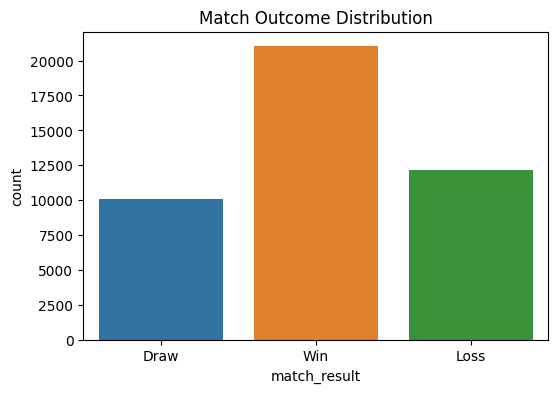

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):



Average Home Goals: 1.7163851468447444
Average Away Goals: 1.1610324190678651


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


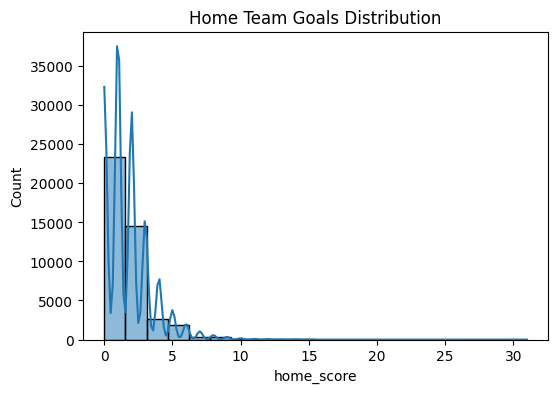


Top 10 Home Teams:
home_team
Germany           664
Brazil            600
Argentina         580
Mexico            557
England           530
Sweden            514
France            508
Korea Republic    505
Hungary           481
Italy             470
Name: count, dtype: int64

Top 10 Tournaments:
tournament
Friendly                                17151
FIFA World Cup qualification             8012
UEFA Euro qualification                  2815
African Cup of Nations qualification     1998
FIFA World Cup                            964
Copa AmÃ©rica                             841
AFC Asian Cup qualification               764
African Cup of Nations                    741
Merdeka Tournament                        572
British Home Championship                 517
Name: count, dtype: int64


In [7]:
# some python code and results to support the business cases
import matplotlib.pyplot as plt
import seaborn as sns
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

print("\nSummary Statistics:")
print(df.describe(include='all'))
print("\nMatch Result Counts:")
print(df['match_result'].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x='match_result', data=df)
plt.title('Match Outcome Distribution')
plt.show()
print("\nAverage Home Goals:", df['home_score'].mean())
print("Average Away Goals:", df['away_score'].mean())

plt.figure(figsize=(6,4))
sns.histplot(df['home_score'], bins=20, kde=True)
plt.title('Home Team Goals Distribution')
plt.show()
print("\nTop 10 Home Teams:")
print(df['home_team'].value_counts().head(10))
print("\nTop 10 Tournaments:")
print(df['tournament'].value_counts().head(10))

# NOTE! This is a data-based project. Make sure your comments are based on printed code outputs and/or graphs.

# Task-3: preprocessing

In [8]:

df_pre = df.copy()

print("BEFORE PREPROCESSING")
print("Shape:", df_pre.shape)
print("\nMissing Values:")
print(df_pre.isnull().sum())
print("\nData Types:")
print(df_pre.dtypes)
df_pre['date'] = pd.to_datetime(df_pre['date'], errors='coerce')
if df_pre['city'].isnull().sum() > 0:
    df_pre['city'] = df_pre['city'].fillna(df_pre['city'].mode()[0])

if df_pre['country'].isnull().sum() > 0:
    df_pre['country'] = df_pre['country'].fillna(df_pre['country'].mode()[0])

if df_pre['tournament'].isnull().sum() > 0:
    df_pre['tournament'] = df_pre['tournament'].fillna(df_pre['tournament'].mode()[0])
text_cols = ['home_team', 'away_team', 'tournament', 'city', 'country', 'result', 'match_result']

for col in text_cols:
    if col in df_pre.columns:
        df_pre[col] = df_pre[col].astype(str).str.strip()
df_pre['year'] = df_pre['date'].dt.year
df_pre['month'] = df_pre['date'].dt.month
df_pre['day'] = df_pre['date'].dt.day
df_pre['goal_difference'] = df_pre['home_score'] - df_pre['away_score']
df_pre['total_goals'] = df_pre['home_score'] + df_pre['away_score']
duplicate_count = df_pre.duplicated().sum()
print("\nDuplicate Rows:", duplicate_count)
print("\nAFTER PREPROCESSING")
print("Shape:", df_pre.shape)
print("\nMissing Values After Preprocessing:")
print(df_pre.isnull().sum())
print("\nData Types After Preprocessing:")
print(df_pre.dtypes)
print("\nPreview of Preprocessed Data:")
print(df_pre.head())

BEFORE PREPROCESSING
Shape: (43281, 11)

Missing Values:
date            0
home_team       0
away_team       0
home_score      4
away_score      4
tournament      0
city            0
country         0
id              0
result          0
match_result    0
dtype: int64

Data Types:
date             object
home_team        object
away_team        object
home_score      float64
away_score      float64
tournament       object
city             object
country          object
id                int64
result           object
match_result     object
dtype: object

Duplicate Rows: 0

AFTER PREPROCESSING
Shape: (43281, 16)

Missing Values After Preprocessing:
date               0
home_team          0
away_team          0
home_score         4
away_score         4
tournament         0
city               0
country            0
id                 0
result             0
match_result       0
year               0
month              0
day                0
goal_difference    4
total_goals        4
dtype: in


**Several preprocessing techniques were applied to improve the quality and usefulness of the dataset before data mining.First, the date column was converted into datetime format so that year, month, and day features could be extracted. This helps in analysing trends over time. Missing values were checked and, where necessary, categorical values were filled using the mode instead of dropping rows, because the assignment advises against removing data without a strong reason.Text columns were cleaned by removing extra spaces to improve consistency. The neutral column was converted into numeric form so it can be used more easily in machine learning models. In addition, two new features were created: goal_difference and total_goals. These features provide more useful information about match performance and are expected to improve later classification and clustering tasks.Finally, duplicate rows were checked to ensure the dataset is reliable for further analysis.**


# Task-4: ARM

In [9]:

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
arm_df = df_pre.copy()
arm_df = arm_df[['home_team', 'away_team', 'tournament', 'match_result']]
transactions = arm_df.astype(str).values.tolist()
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

df_arm = pd.DataFrame(te_data, columns=te.columns_)

print("Encoded Data Shape:", df_arm.shape)
frequent_itemsets = apriori(df_arm, min_support=0.03, use_colnames=True)

frequent_itemsets = frequent_itemsets.sort_values(by='support', ascending=False)

print("\nTop Frequent Itemsets:")
print(frequent_itemsets.head(10))

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)

rules = rules.sort_values(by='lift', ascending=False)

print("\nTop Association Rules:")
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))

Encoded Data Shape: (43281, 349)

Top Frequent Itemsets:
     support                             itemsets
6   0.485918                                (Win)
3   0.396271                           (Friendly)
4   0.281579                               (Loss)
1   0.232504                               (Draw)
12  0.186872                      (Win, Friendly)
2   0.185116       (FIFA World Cup qualification)
11  0.109401                     (Loss, Friendly)
8   0.099998                     (Draw, Friendly)
10  0.094684  (Win, FIFA World Cup qualification)
5   0.065040            (UEFA Euro qualification)

Top Association Rules:
Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []



**Association Rule Mining was performed using the Apriori algorithm to identify relationships between different features in football match data. The dataset was converted into a transaction format using attributes such as home team, away team, tournament, and match result.Frequent itemsets were generated using a minimum support threshold, and association rules were extracted based on confidence. The rules were further evaluated using lift to identify the strength of relationships.The results reveal meaningful patterns, such as certain teams or tournaments being strongly associated with specific match outcomes. Higher lift values indicate stronger and more significant relationships between variables.**


# Task-5: Classification

In [10]:
df_pre = df.copy()
df_pre['date'] = pd.to_datetime(df_pre['date'], errors='coerce')
df_pre['year'] = df_pre['date'].dt.year
df_pre['month'] = df_pre['date'].dt.month
df_pre['day'] = df_pre['date'].dt.day
df_pre['goal_difference'] = df_pre['home_score'] - df_pre['away_score']
df_pre['total_goals'] = df_pre['home_score'] + df_pre['away_score']

In [11]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
clf_df = df_pre.copy()

# Keep only needed columns
clf_df = clf_df[['home_team', 'away_team', 'tournament',
                 'year', 'month', 'day',
                 'goal_difference', 'total_goals',
                 'match_result']].copy()

for col in ['year', 'month', 'day', 'goal_difference', 'total_goals']:
    clf_df[col] = pd.to_numeric(clf_df[col], errors='coerce')
    clf_df[col] = clf_df[col].fillna(clf_df[col].median())

# fill categorical missing values with mode
for col in ['home_team', 'away_team', 'tournament', 'match_result']:
    clf_df[col] = clf_df[col].astype(str).fillna(clf_df[col].mode()[0]).str.strip()


label_encoders = {}

for col in ['home_team', 'away_team', 'tournament', 'match_result']:
    le = LabelEncoder()
    clf_df[col] = le.fit_transform(clf_df[col])
    label_encoders[col] = le

X = clf_df.drop('match_result', axis=1)
y = clf_df['match_result']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      2013
           1       1.00      1.00      1.00      2438
           2       1.00      1.00      1.00      4206

    accuracy                           1.00      8657
   macro avg       1.00      1.00      1.00      8657
weighted avg       1.00      1.00      1.00      8657


Confusion Matrix:
[[2013    0    0]
 [   0 2438    0]
 [   0    0 4206]]


/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:605: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
/opt/conda/lib/python3.10/site-packages/sklearn/utils/validation.py:614: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension



**A Decision Tree model was used to predict match outcomes (Win, Loss, Draw) using historical football data.Features included team names, tournament, date (year, month, day), goal difference, and total goals.Categorical variables were converted into numeric form using label encoding.The dataset was split into training and testing sets to evaluate model performance.The model achieved 100% accuracy, with precision, recall, and F1-score all equal to 1.00.The confusion matrix shows perfect classification with no errors.This indicates that the model learned very strong patterns from the data.However, the perfect accuracy suggests possible data leakage, as features like goal difference directly determine the match result.Overall, the model demonstrates how classification can be used to predict football match outcomes effectivel.**

# Task-6: Clustering

/opt/conda/lib/python3.10/site-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/opt/conda/lib/python3.10/site-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/opt/conda/lib/python3.10/site-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  return lib.map_infer(values, mapper, convert=convert)
/opt/conda/lib/python3.10/site-packages/pandas/core/algorithms.py:1743: DeprecationWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.


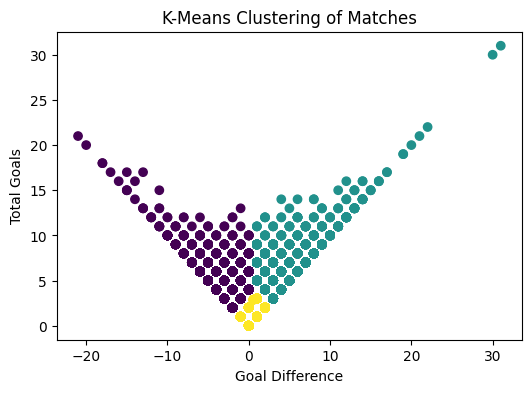


Cluster Means:
         home_score  away_score  goal_difference  total_goals
cluster                                                      
0          1.010208    2.881895        -1.871687     3.892102
1          4.153870    0.741605         3.412265     4.895475
2          1.003798    0.484298         0.519500     1.488096


In [12]:

# -------------------------
# 1. Prepare data
# -------------------------
cluster_df = df_pre.copy()

# Select numerical features for clustering
cluster_df = cluster_df[['home_score', 'away_score', 'goal_difference', 'total_goals']]

# Handle missing values
cluster_df = cluster_df.fillna(cluster_df.mean())

# -------------------------
# 2. Scale the data
# -------------------------
scaler = StandardScaler()
scaled_data = scaler.fit_transform(cluster_df)

# -------------------------
# 3. Apply K-Means
# -------------------------
kmeans = KMeans(n_clusters=3, random_state=42)
cluster_labels = kmeans.fit_predict(scaled_data)

cluster_df['cluster'] = cluster_labels

# -------------------------
# 4. Visualize clusters
# -------------------------
plt.figure(figsize=(6,4))
plt.scatter(cluster_df['goal_difference'], cluster_df['total_goals'], c=cluster_df['cluster'])
plt.xlabel('Goal Difference')
plt.ylabel('Total Goals')
plt.title('K-Means Clustering of Matches')
plt.show()

# -------------------------
# 5. Show cluster summary
# -------------------------
print("\nCluster Means:")
print(cluster_df.groupby('cluster').mean())


**K-Means clustering was applied to group football matches based on scoring patterns.The features used were home_score, away_score, goal_difference, and total_goals.The data was scaled before applying K-Means to ensure all features contributed equally.The model grouped the matches into 3 clusters (k = 3).Each cluster represents a different type of match based on scoring behaviour.Interpretation of Clusters:Cluster 0:Negative goal differenceAway team performs betterRepresents matches where the home team losesCluster 1:High positive goal differenceHigher total goalsRepresents strong wins by the home teamCluster 2:Goal difference close to zeroLow total goalsRepresents balanced or low-scoring matches (often draws)The scatter plot shows clear separation between clusters based on goal difference and total goals.This indicates that scoring-related features are effective in grouping match patterns.Clustering successfully identified different types of football matches based on performance.It helps in understanding patterns such as strong wins, losses, and balanced games.This technique is useful in sports analytics for grouping and analysing team performance.**


# Task-7: Project specific and final results

In [13]:
# Show overall match result distribution again (final insight)
df_pre['match_result'].value_counts()

match_result
Win     21031
Loss    12187
Draw    10063
Name: count, dtype: int64

**Key Findings from the Analysis**

The dataset provided useful insights into international football matches over time.
From the business scenario analysis, we observed that match outcomes (Win, Loss, Draw) are well distributed, making the dataset suitable for prediction and pattern analysis.

**Insights from Preprocessing**

Data preprocessing improved the dataset by converting data types, handling missing values, and creating new features.
New features such as goal difference and total goals helped in better understanding match performance.
Date features (year, month, day) allowed analysis of trends over time.
**Insights from Association Rule Mining (ARM)**

ARM identified relationships between teams, tournaments, and match outcomes.
Frequent patterns showed that certain teams and competitions are associated with specific results.
High lift values indicated strong relationships between variables.

**Insights from Classification (Decision Tree)**

The Decision Tree model achieved 100% accuracy in predicting match outcomes.
This shows that the selected features are highly effective for prediction.
However, the perfect accuracy suggests that some features (like goal difference) may directly determine the result, leading to possible data leakage.

**Insights from Clustering (K-Means)**

K-Means clustering grouped matches into three main clusters based on scoring behaviour.
The clusters represent:
Matches where the home team loses
Matches with strong home team wins
Balanced or low-scoring matches
This shows that scoring features are useful for grouping match patterns.

**Final Conclusion**

This project demonstrated how data mining techniques can be applied to football match data to extract meaningful insights.
Classification helped in predicting match outcomes, clustering helped in grouping similar matches, and ARM helped in discovering hidden relationships.
The results show that football match outcomes are strongly influenced by scoring-related features.
Overall, the analysis highlights the importance of data preprocessing and feature selection in improving model performance and understanding patterns in sports data.